In [1]:
import matplotlib .pyplot as plt
import numpy as np
import pandas as pd

In [3]:
df=pd.read_csv('iq_cgpa_org.csv')
df.head()

,IQ,CGPA
0,6.75,2.70
1,1.23,0.06
2,3.48,1.30
3,3.01,1.35
4,7.63,2.88


In [4]:
df.shape

(1000, 2)

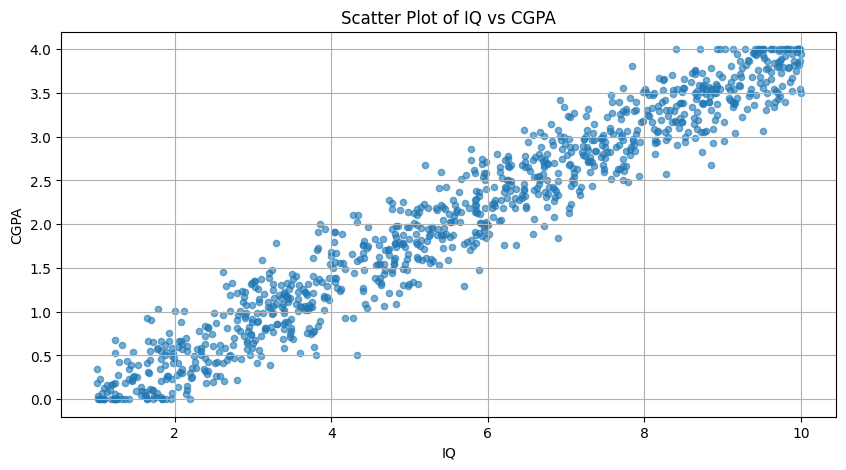

In [7]:
plt.figure(figsize=(10,5))
plt.scatter(df['IQ'],df['CGPA'],s=20,alpha=0.6)

plt.xlabel('IQ')
plt.ylabel('CGPA')
plt.title('Scatter Plot of IQ vs CGPA')
plt.grid(True)
plt.show()

In [13]:
x=df.iloc[:,0:1]
y=df.iloc[:,-1]

In [14]:
x

,IQ
0,6.75
1,1.23
2,3.48
3,3.01
4,7.63
...,...
995,1.29
996,4.33
997,4.99
998,9.55


In [15]:
y

0      2.70
1      0.06
2      1.30
3      1.35
4      2.88
       ... 
995    0.04
996    2.02
997    1.97
998    3.63
999    3.59
Name: CGPA, Length: 1000, dtype: float64

In [16]:
from sklearn.model_selection import train_test_split
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.2,random_state=42)

In [17]:
x_train

,IQ
29,6.43
535,7.90
695,6.63
557,9.85
836,6.89
...,...
106,2.00
270,8.35
860,8.85
435,1.45


In [18]:
from sklearn.linear_model import LinearRegression
model=LinearRegression()
model.fit(x_train,y_train)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [24]:
LinearRegression()

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [27]:
m=model.coef_
m

array([0.44260382])

In [29]:
b=model.intercept_
b


-0.4255864973180836

In [30]:
np.float64(-0.4255869731808273)

-0.4255869731808273

In [31]:
df

,IQ,CGPA
0,6.75,2.70
1,1.23,0.06
2,3.48,1.30
3,3.01,1.35
4,7.63,2.88
...,...,...
995,1.29,0.04
996,4.33,2.02
997,4.99,1.97
998,9.55,3.63


In [32]:
m*7.63+b

array([2.95148062])

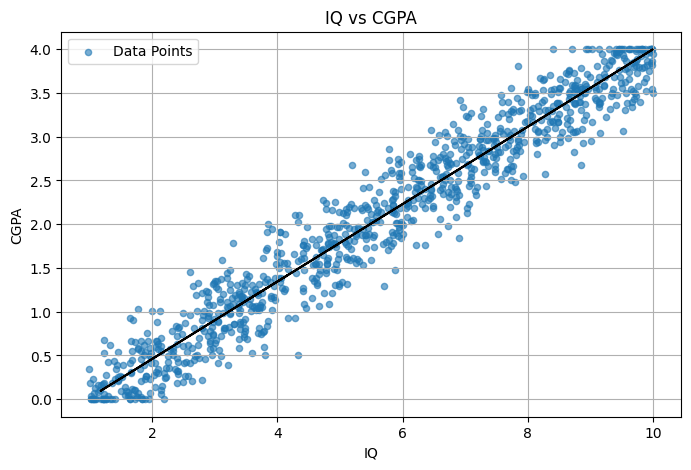

In [34]:
plt.figure(figsize=(8,5))
plt.scatter(df['IQ'],df['CGPA'],s=20,alpha=0.6,label='Data Points')
plt.plot(x_test,model.predict(x_test),color='black')

plt.xlabel('IQ')
plt.ylabel('CGPA')
plt.title('IQ vs CGPA')
plt.grid(True)
plt.legend()
plt.show()

In [35]:
from sklearn.metrics import mean_squared_error,r2_score,mean_absolute_error
y_train.squeeze()


29     2.33
535    3.08
695    2.41
557    3.80
836    3.08
       ... 
106    1.01
270    3.70
860    3.55
435    0.22
102    2.63
Name: CGPA, Length: 800, dtype: float64

In [36]:
import math

In [41]:
y_pred=model.predict(x_test)
print(f"MAE=> {mean_absolute_error(y_test,y_pred)}")
print(f"MSE=> {mean_squared_error(y_test,y_pred)}")
print(f"RMSE=> {math.sqrt(mean_squared_error(y_test,y_pred))}")
print(f"R²=> {r2_score(y_test,y_pred)}")

MAE=> 0.21761282491267914
MSE=> 0.0747040752677109
RMSE=> 0.2733204625850595
R²=> 0.9496581378365819
